# CSE 445 — Computer Vision
## Part B — Notebook 3a: I-JEPA Pretraining on the KIIT-MiTA SSL Pool

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA — High-Resolution Drone Imagery for Military Object Detection and Recognition. |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Model** | I-JEPA Detect |

---

### I-JEPA (Image Joint-Embedding Predictive Architecture)

A target encoder (EMA of the online encoder, same mechanism as BYOL) produces the complete spatial
feature map for an image. Several rectangular **target blocks** are sampled on that map; their
corresponding image regions are hidden from the online **context** encoder. A lightweight predictor
then tries to predict the target encoder's latent features for the hidden blocks, from the visible
context alone — prediction happens in **representation space**, not pixel space, and there is no
hand-crafted view augmentation (no crop/colour-jitter pairs like SimCLR/BYOL). The loss is Smooth L1
between predicted and target latents. This is a compute-scaled, YOLO-native adaptation of I-JEPA, not a
reproduction of the original ViT-H training regime worth stating explicitly in the report.


**What this notebook does**

- Pretrains a YOLOv26n backbone with I-JEPA using `ssldet`, on the unlabelled SSL pool (labels discarded).
- Visualizes sampled target blocks, plots the SSL loss + target-momentum curves, extracts validation
   features, runs t-SNE + nearest-neighbour diagnostics, a shortcut-learning check on the train pool,
   and quantitative collapse checks.

## 1. Install `ssldet` and imports

In [1]:
%pip install -q --upgrade "git+https://github.com/rifat963/ssl-detection-lab.git@main" scikit-learn seaborn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from packaging.version import Version
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from ultralytics import YOLO

import ssldet
from ssldet import PretrainConfig, launch_distributed_pretrain
from ssldet.backbones import YOLOBackboneEncoder
from ssldet.data import IMAGENET_MEAN, IMAGENET_STD, UnlabeledImageDataset, build_transform
from ssldet.ssl import create_ssl_module, sample_target_blocks

random.seed(0); np.random.seed(0); torch.manual_seed(0); torch.cuda.manual_seed_all(0)
torch.set_float32_matmul_precision("high")
sns.set_theme(style="whitegrid", context="notebook")

REQUIRED_SSLDET_VERSION = "0.8.1"
assert Version(ssldet.__version__) >= Version(REQUIRED_SSLDET_VERSION), (
    f"ssldet {ssldet.__version__} found, need >= {REQUIRED_SSLDET_VERSION}. "
    "Restart the kernel/session and rerun the install cell from the top, then re-run this cell."
)
print("ssl-detection-lab version:", ssldet.__version__)
assert torch.cuda.is_available(), "Select a GPU accelerator before continuing."

GPU_COUNT = torch.cuda.device_count()
DEVICE = torch.device("cuda:0")
print("GPUs:", GPU_COUNT)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ssl-detection-lab version: 0.9.0
GPUs: 2


## 2. Attach the Part B data-prep output (partition + SSL pool, already built)

In [3]:
import pathlib, json, yaml

_manifest_candidates = list(pathlib.Path("/kaggle/input").rglob("partition_manifest.json"))
if not _manifest_candidates:
    raise FileNotFoundError(
        "No partition_manifest.json found under /kaggle/input. "
        "Attach group02-partB-00-data-prep's output as an input to this notebook."
    )
PARTITION_MANIFEST_PATH = _manifest_candidates[0]
partition_manifest = json.loads(PARTITION_MANIFEST_PATH.read_text())
BASE_DIR = PARTITION_MANIFEST_PATH.parent

SEED = partition_manifest["seed"]
CLASS_NAMES = partition_manifest["class_names"]
NUM_CLASSES = len(CLASS_NAMES)
TARGET_RATIO = partition_manifest["target_ratio_copy_paste"]

RESPLIT_ROOT = BASE_DIR / "dataset-resplit"
SSL_POOL_TRAIN_DIR = RESPLIT_ROOT / "train" / "images"
SSL_POOL_VAL_DIR = RESPLIT_ROOT / "val" / "images"
SSL_POOL_TEST_DIR = RESPLIT_ROOT / "test" / "images"

for d in [SSL_POOL_TRAIN_DIR, SSL_POOL_VAL_DIR, SSL_POOL_TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Expected directory missing: {d}")

stems_train = partition_manifest["stems_ssl_pool_raw"]
stems_val = partition_manifest["stems_val"]
stems_test = partition_manifest["stems_test"]

print("SSL pool (train) dir:", SSL_POOL_TRAIN_DIR, "| raw stems:", len(stems_train))
print("Val dir             :", SSL_POOL_VAL_DIR, "| stems:", len(stems_val))
print("Test dir            :", SSL_POOL_TEST_DIR, "| stems:", len(stems_test))
print("Classes:", CLASS_NAMES)

SSL pool (train) dir: /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/train/images | raw stems: 1339
Val dir             : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/val/images | stems: 164
Test dir            : /kaggle/input/notebooks/arifulislamopi/group02-dataset-eda/dataset-resplit/test/images | stems: 178
Classes: ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']


## 3. Inspect the dataset

Total image counts per split, a per-class instance-count table across all three splits, and a sample
grid of raw training images.


In [4]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
def image_files(directory):
    return sorted(p for p in Path(directory).rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)

train_images = image_files(SSL_POOL_TRAIN_DIR)
val_images = image_files(SSL_POOL_VAL_DIR)
test_images = image_files(SSL_POOL_TEST_DIR)

pd.Series({
    "train — raw stems (pre copy-paste)": len(stems_train),
    "train — on disk (raw + copy-paste)": len(train_images),
    "train — copy-paste synthetic added": len(train_images) - len(stems_train),
    "val — on disk (always raw, never augmented)": len(val_images),
    "test — on disk (always raw, never augmented)": len(test_images),
    "TOTAL images on disk (train + val + test)": len(train_images) + len(val_images) + len(test_images),
})

train — raw stems (pre copy-paste)              1339
train — on disk (raw + copy-paste)              2377
train — copy-paste synthetic added              1038
val — on disk (always raw, never augmented)      164
test — on disk (always raw, never augmented)     178
TOTAL images on disk (train + val + test)       2719
dtype: int64

In [5]:
def count_class_instances(labels_dir):
    counts = Counter()
    for lbl_path in Path(labels_dir).glob("*.txt"):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return counts

train_label_counts = count_class_instances(RESPLIT_ROOT / "train" / "labels")
val_label_counts = count_class_instances(RESPLIT_ROOT / "val" / "labels")
test_label_counts = count_class_instances(RESPLIT_ROOT / "test" / "labels")

class_table = pd.DataFrame({
    "train (raw+copy-paste)": [train_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "val": [val_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "test": [test_label_counts.get(i, 0) for i in range(NUM_CLASSES)],
}, index=CLASS_NAMES)
class_table["total"] = class_table.sum(axis=1)
class_table.index.name = "class name"
class_table

,train (raw+copy-paste),val,test,total
class name,,,,
Artilary,610,29,28,667
Missile,764,40,45,849
Radar,772,33,29,834
M. Rocket Launcher,705,33,36,774
Soldier,937,113,92,1142
Tank,824,81,94,999
Vehicle,1033,93,159,1285


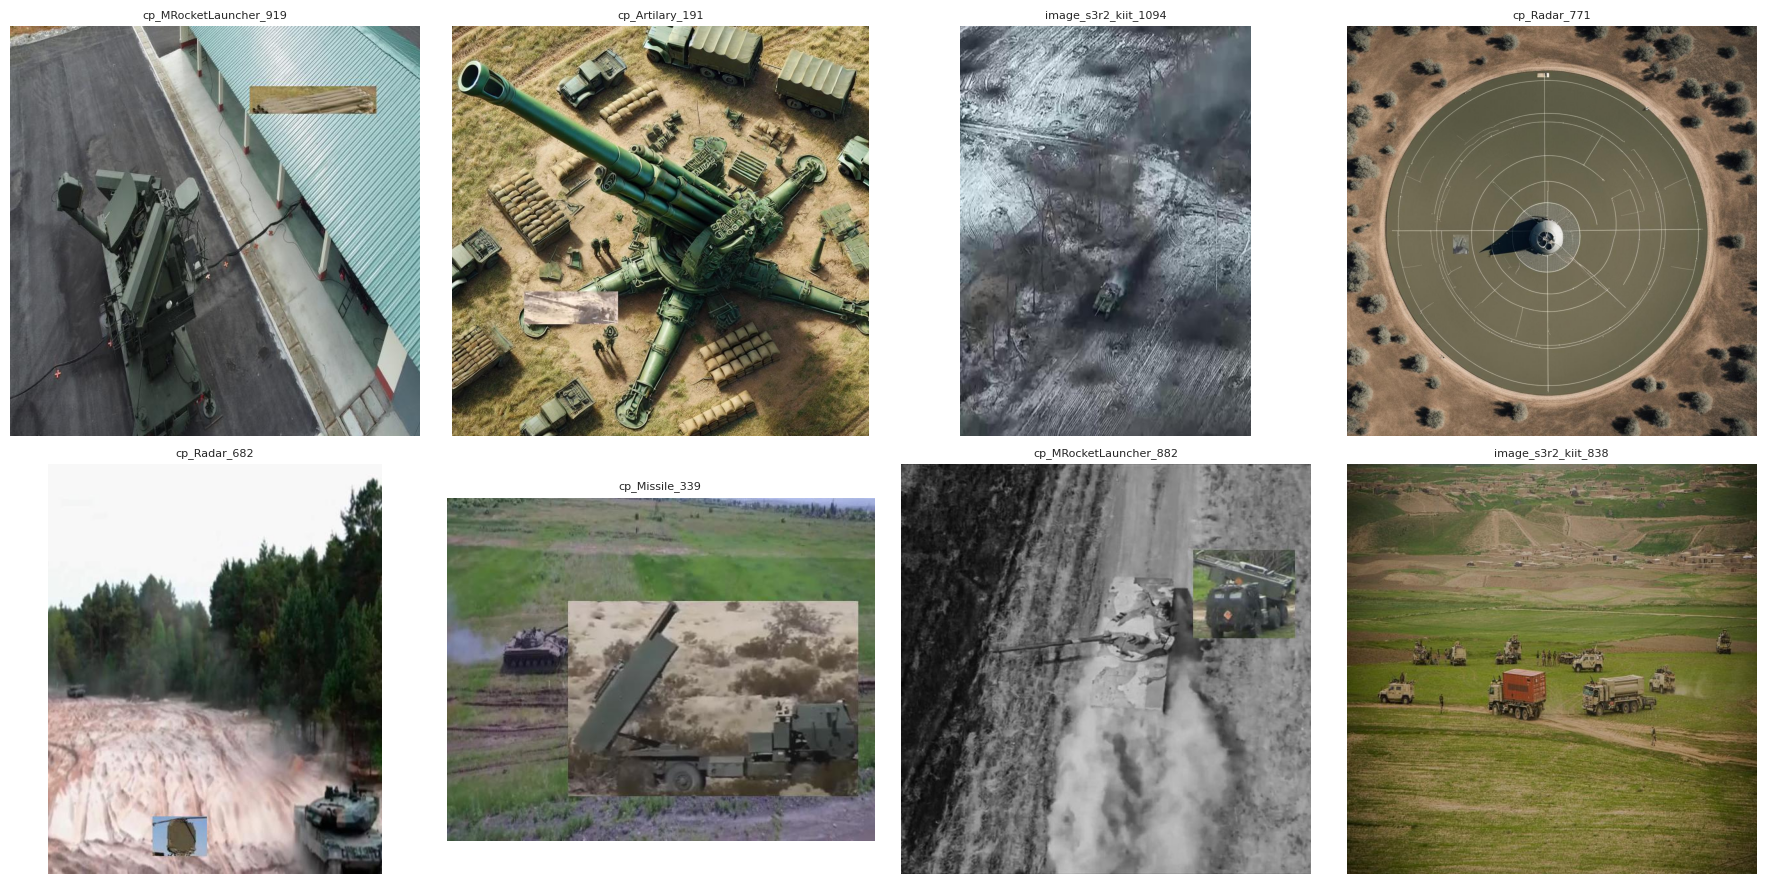

In [6]:
sample_train_paths = random.Random(SEED).sample(train_images, min(8, len(train_images)))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, p in zip(axes.flat, sample_train_paths):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem[:28], fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 4. I-JEPA config

Epoch budget and batch size are fixed across all four SSL methods and both baselines (fairness): here
that means `epochs=200`, `batch_size=32` per GPU (`64` total), `image_size=224` — the same as
SimCLR/BYOL, even though the reference tutorial's own "full" preset used `batch=16`/`image_size=224`/
`epochs=25`; we keep our shared 200-epoch, batch=64-total budget for cross-method fairness rather than
this method's own suggested defaults. `warmup_epochs=10` (5%, matching the longer schedule).

In [7]:
METHOD = "ijepa"
PRETRAIN_OUTPUT_DIR = f"/kaggle/working/{METHOD}_kiitmita"

config = PretrainConfig(
    method=METHOD,
    image_roots=[str(SSL_POOL_TRAIN_DIR)],
    output_dir=PRETRAIN_OUTPUT_DIR,
    yolo_model="yolo26n.yaml",
    epochs=200,
    batch_size=32,
    image_size=224,
    workers=2,
    seed=SEED,
    learning_rate=3e-4,
    min_learning_rate=3e-6,
    weight_decay=1e-4,
    warmup_epochs=10,
    grad_accum_steps=1,
    gradient_clip=5.0,
    amp=True,
    projection_dim=256,
    momentum=0.996,
    final_momentum=1.0,
    num_target_blocks=4,
    target_scale_min=0.10,
    target_scale_max=0.25,
    target_aspect_min=0.75,
    target_aspect_max=1.50,
    predictor_depth=2,
    predictor_heads=4,
    save_every=5,
).validate()

pd.Series({
    "epochs": config.epochs, "SSL pool images": len(train_images), "image size": config.image_size,
    "batch per GPU": config.batch_size, "target blocks": config.num_target_blocks,
    "target scale": (config.target_scale_min, config.target_scale_max),
    "projection dimensions": config.projection_dim, "AMP": config.amp,
})

epochs                           200
SSL pool images                 2377
image size                       224
batch per GPU                     32
target blocks                      4
target scale             (0.1, 0.25)
projection dimensions            256
AMP                             True
dtype: object

## 5. Visualize an input and its sampled target blocks

Masks are sampled on the final YOLO backbone grid (`image_size // 32`); during training their union is
expanded to image resolution and hidden from the context encoder.


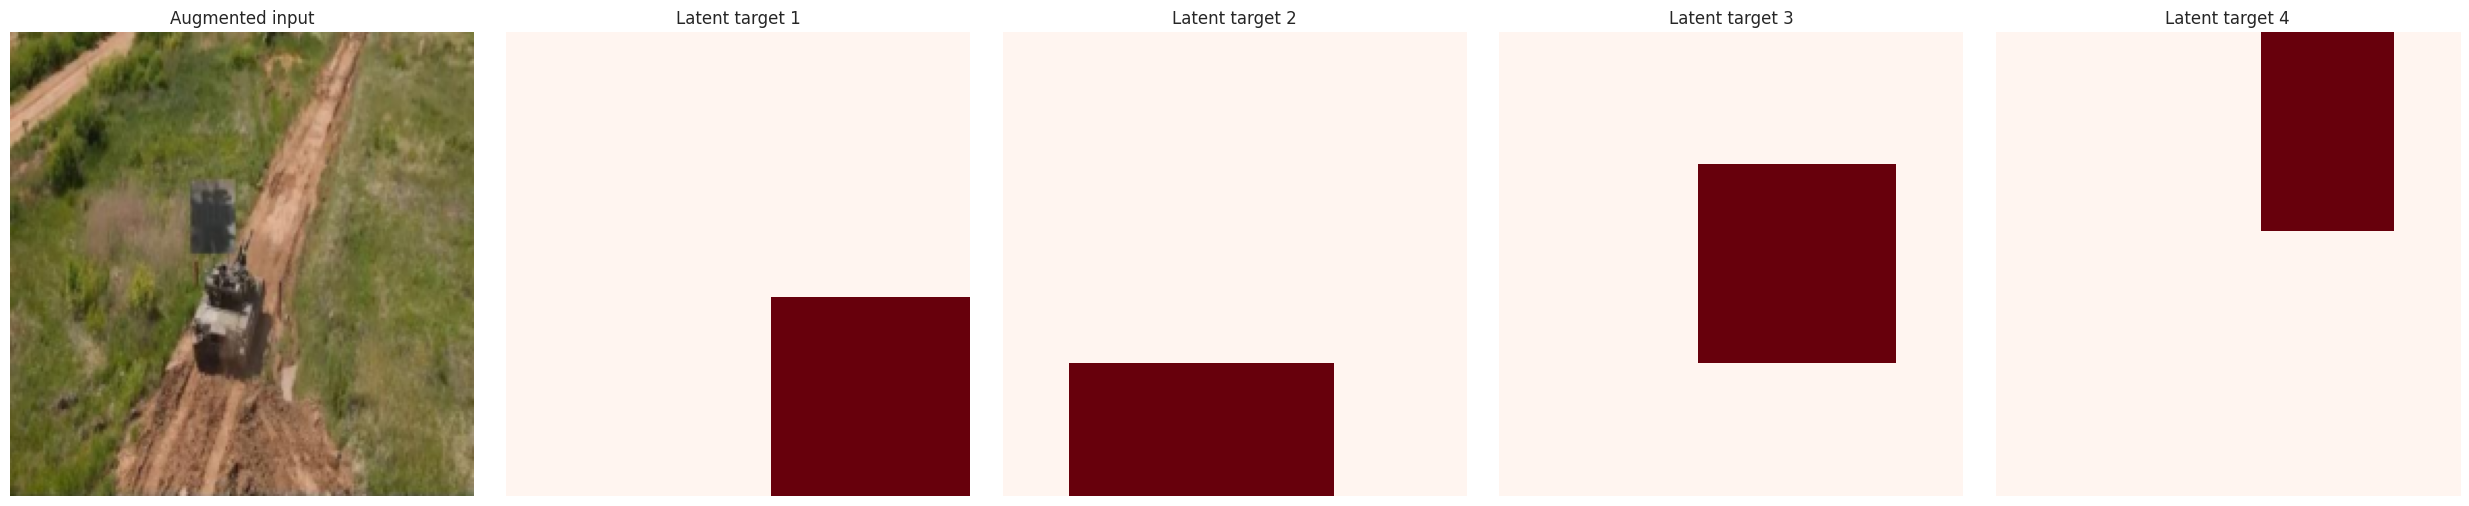

In [8]:
preview_dataset = UnlabeledImageDataset(train_images, build_transform(config))
preview = preview_dataset[0]
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
display_image = (preview * std + mean).clamp(0, 1).permute(1, 2, 0)

grid_size = config.image_size // 32
masks = sample_target_blocks(
    1, grid_size, grid_size, config.num_target_blocks,
    (config.target_scale_min, config.target_scale_max),
    (config.target_aspect_min, config.target_aspect_max),
    torch.device("cpu"),
)[0]

fig, axes = plt.subplots(1, config.num_target_blocks + 1, figsize=(5 * (config.num_target_blocks + 1), 5))
axes[0].imshow(display_image); axes[0].set_title("Augmented input")
for index, mask in enumerate(masks, start=1):
    axes[index].imshow(mask, cmap="Reds", vmin=0, vmax=1); axes[index].set_title(f"Latent target {index}")
for axis in axes:
    axis.axis("off")
plt.tight_layout(); plt.show()

## 6. Sanity check — target encoder must be frozen (updates only via EMA)

In [9]:
probe_detector = YOLO(config.yolo_model)
probe_encoder = YOLOBackboneEncoder(probe_detector.model).to(DEVICE)
feature_channels, _, _ = probe_encoder.infer_dimensions(config.image_size, DEVICE)

ijepa_module = create_ssl_module(
    "ijepa", encoder=probe_encoder, feature_channels=feature_channels,
    projection_dim=config.projection_dim, predictor_depth=config.predictor_depth,
    predictor_heads=config.predictor_heads, momentum=config.momentum,
    num_target_blocks=config.num_target_blocks,
    target_scale=(config.target_scale_min, config.target_scale_max),
    target_aspect=(config.target_aspect_min, config.target_aspect_max),
).to(DEVICE)

with torch.inference_mode(), torch.amp.autocast("cuda"):
    example_loss = ijepa_module(preview.unsqueeze(0).to(DEVICE))

pd.Series({
    "feature channels": feature_channels, "example loss": float(example_loss),
    "target encoder trainable (should be False)": any(p.requires_grad for p in ijepa_module.target_encoder.parameters()),
})

feature channels                                   256
example loss                                  0.734185
target encoder trainable (should be False)       False
dtype: object

In [10]:
del ijepa_module, probe_encoder, probe_detector, example_loss
torch.cuda.empty_cache()

## 7. Launch I-JEPA pretraining (200 epochs, distributed across both T4s)

In [11]:
training_result = launch_distributed_pretrain(
    config, num_processes=GPU_COUNT,
    config_path=f"{PRETRAIN_OUTPUT_DIR}/ijepa_config.yaml", check=True,
)
pd.Series({"completed": training_result.succeeded, "seconds": round(training_result.seconds, 1),
           "output directory": str(training_result.output_dir)})

IJEPA 01/200: 100%|██████████| 37/37 [00:37<00:00,  1.01s/it, ema=0.99600, loss=0.5689, lr=3.08e-05]


Epoch 01 | loss=0.56904 | time=37.4s


IJEPA 03/200:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 02 | loss=0.14395 | time=11.8s


IJEPA 03/200: 100%|██████████| 37/37 [00:11<00:00,  3.30it/s, ema=0.99600, loss=0.0222, lr=9.08e-05]


...

IJEPA 200/200: 100%|██████████| 37/37 [00:12<00:00,  3.08it/s, ema=1.00000, loss=0.1359, lr=3.00e-06]


Epoch 200 | loss=0.13415 | time=12.0s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/ijepa_kiitmita",
  "yolo_checkpoint": "/kaggle/working/ijepa_kiitmita/ijepa_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_kiitmita/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_kiitmita/history.csv",
  "manifest_json": "/kaggle/working/ijepa_kiitmita/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/ijepa_kiitmita",
  "yolo_checkpoint": "/kaggle/working/ijepa_kiitmita/ijepa_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_kiitmita/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_kiitmita/history.csv",
  "manifest_json": "/kaggle/working/ijepa_kiitmita/run_manifest.json"
}


completed                                     True
seconds                                     2464.0
output directory    /kaggle/working/ijepa_kiitmita
dtype: object

## 8. Loss and target-momentum curves

,epoch,loss,learning_rate,ema_momentum,seconds
0,1,0.569040,0.000031,0.996000,37.359013
1,2,0.143946,0.000061,0.996001,11.826179
2,3,0.022077,0.000091,0.996002,11.211811
3,4,0.056019,0.000121,0.996004,11.915444
4,5,0.203558,0.000151,0.996006,11.995518
...,...,...,...,...,...
195,196,0.131460,0.000003,0.999996,12.298449
196,197,0.135238,0.000003,0.999998,12.114808
197,198,0.134231,0.000003,0.999999,11.810776
198,199,0.133193,0.000003,1.000000,11.888285


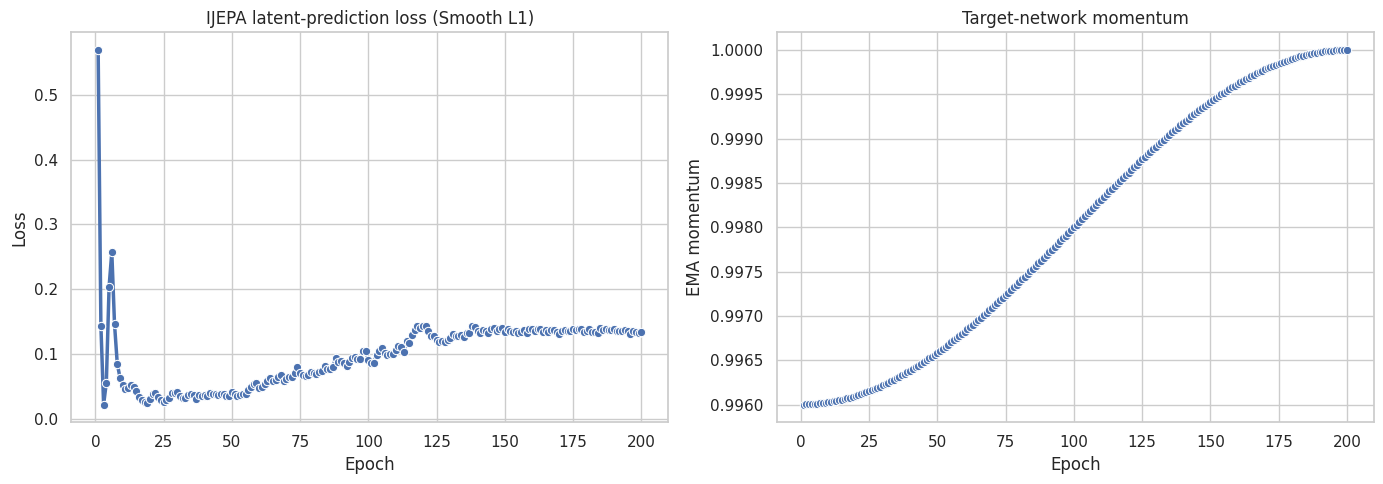

In [12]:
history = pd.read_csv(f"{PRETRAIN_OUTPUT_DIR}/history.csv")
display(history.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=history, x="epoch", y="loss", marker="o", linewidth=2.5, ax=axes[0])
sns.lineplot(data=history, x="epoch", y="ema_momentum", marker="o", linewidth=2.5, ax=axes[1])
axes[0].set_title(f"{METHOD.upper()} latent-prediction loss (Smooth L1)"); axes[0].set_ylabel("Loss")
axes[1].set_title("Target-network momentum"); axes[1].set_ylabel("EMA momentum")
for ax in axes:
    ax.set_xlabel("Epoch"); ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

## 9. Locate the exported checkpoints

In [13]:
manifest = json.loads((Path(PRETRAIN_OUTPUT_DIR) / "run_manifest.json").read_text())
YOLO_CHECKPOINT = Path(manifest["outputs"]["yolo_checkpoint"])
SSL_CHECKPOINT = Path(manifest["outputs"]["ssl_checkpoint"])

pd.Series({
    "initialization": manifest["initialization"], "unlabeled images": manifest["unlabeled_images"],
    "world size": manifest["world_size"], "best loss": manifest["best_loss"],
    "YOLO checkpoint": str(YOLO_CHECKPOINT), "full I-JEPA checkpoint": str(SSL_CHECKPOINT),
})

initialization            random initialization; strict label-free SSL p...
unlabeled images                                                       2377
world size                                                                2
best loss                                                          0.022077
YOLO checkpoint           /kaggle/working/ijepa_kiitmita/ijepa_pretraine...
full I-JEPA checkpoint           /kaggle/working/ijepa_kiitmita/last_ssl.pt
dtype: object

## 10. Extract validation features

Embed every validation image with the trained backbone. Validation images are always 100% raw (never
copy-paste-augmented), so this is a clean generalisation check.


In [14]:
import torchvision.transforms.v2 as v2

detector = YOLO(str(YOLO_CHECKPOINT))
encoder = YOLOBackboneEncoder(detector.model).to(DEVICE).eval()
infer_tf = v2.Compose([v2.Resize((config.image_size, config.image_size)), v2.ToImage(),
                        v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

EMBEDDING_LIMIT = 200
selected_paths = val_images if len(val_images) <= EMBEDDING_LIMIT else random.Random(SEED).sample(val_images, EMBEDDING_LIMIT)

feats, paths = [], []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        feats.append(feat.squeeze(0).cpu().numpy())
        paths.append(p)

feature_matrix = np.stack(feats)
pd.Series({
    "images": float(len(feature_matrix)),
    "feature dimensions": float(feature_matrix.shape[1]),
    "feature norm mean": float(np.linalg.norm(feature_matrix, axis=1).mean()),
})

Embedding val images:   0%|          | 0/164 [00:00<?, ?it/s]

images                164.0
feature dimensions    256.0
feature norm mean       1.0
dtype: float64

## 11. t-SNE of validation embeddings, coloured by dominant class

Val labels exist on disk (only the SSL-pool/train labels are unused for pretraining) — colour by each
image's dominant class using them, so this plot actually shows colour variation.


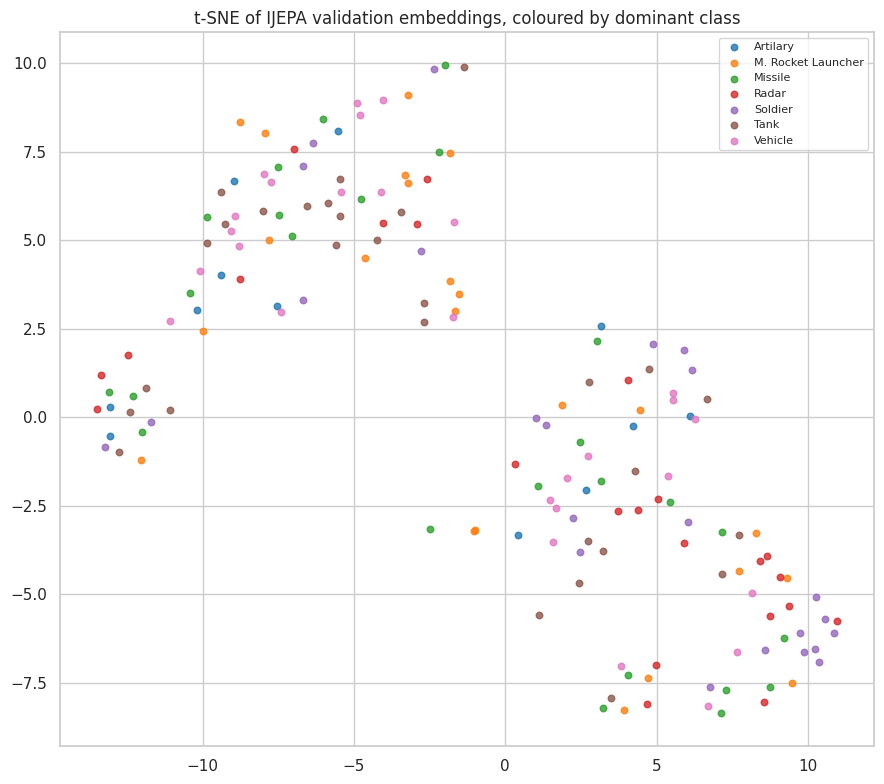

In [15]:
def dominant_class_for_stem(stem, labels_dir):
    lbl_path = Path(labels_dir) / f"{stem}.txt"
    counts = Counter()
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(float(parts[0]))] += 1
    return CLASS_NAMES[counts.most_common(1)[0][0]] if counts else "No Label"

val_labels_dir = RESPLIT_ROOT / "val" / "labels"
point_classes = [dominant_class_for_stem(p.stem, val_labels_dir) for p in paths]

perplexity = min(30.0, max(2.0, (len(feature_matrix) - 1) / 3))
tsne_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(9, 8))
palette = sns.color_palette("tab10", n_colors=len(set(point_classes)))
for color, cls in zip(palette, sorted(set(point_classes))):
    idx = [i for i, c in enumerate(point_classes) if c == cls]
    ax.scatter(tsne_xy[idx, 0], tsne_xy[idx, 1], label=cls, s=22, alpha=0.8, color=color)
ax.legend(fontsize=8, loc="best"); ax.set_title(f"t-SNE of {METHOD.upper()} validation embeddings, coloured by dominant class")
plt.tight_layout(); plt.show()

## 12. Nearest-neighbour retrieval

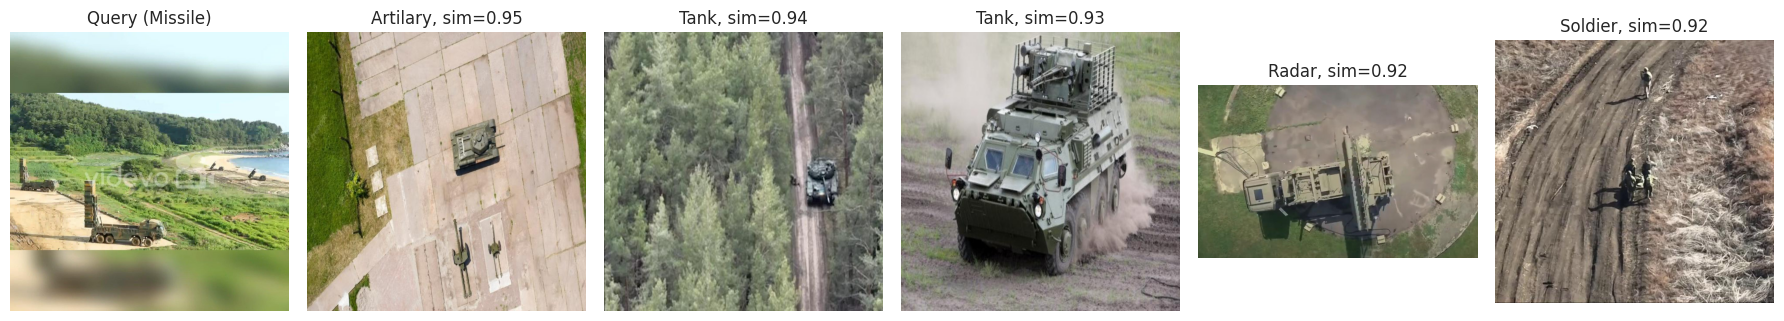

In [16]:
sims = cosine_similarity(feature_matrix)
QUERY_INDEX = 0
NEIGHBOR_COUNT = min(5, len(feature_matrix) - 1)
neighbour_idx = np.argsort(-sims[QUERY_INDEX])[1:NEIGHBOR_COUNT + 1]

fig, axes = plt.subplots(1, NEIGHBOR_COUNT + 1, figsize=(3 * (NEIGHBOR_COUNT + 1), 3.2))
axes[0].imshow(Image.open(paths[QUERY_INDEX]))
axes[0].set_title(f"Query ({point_classes[QUERY_INDEX]})"); axes[0].axis("off")
for ax, idx in zip(axes[1:], neighbour_idx):
    ax.imshow(Image.open(paths[idx])); ax.set_title(f"{point_classes[idx]}, sim={sims[QUERY_INDEX, idx]:.2f}"); ax.axis("off")
plt.tight_layout(); plt.show()

## 13. Shortcut-learning check — raw vs. copy-paste synthetic, on the TRAIN pool

This check needs images that actually include copy-paste synthetics, so it runs on the **train** pool
specifically (not validation, which is always 100% raw and would show only one colour here).


Embedding train-pool images:   0%|          | 0/300 [00:00<?, ?it/s]

Raw: 155 | Copy-paste synthetic: 145


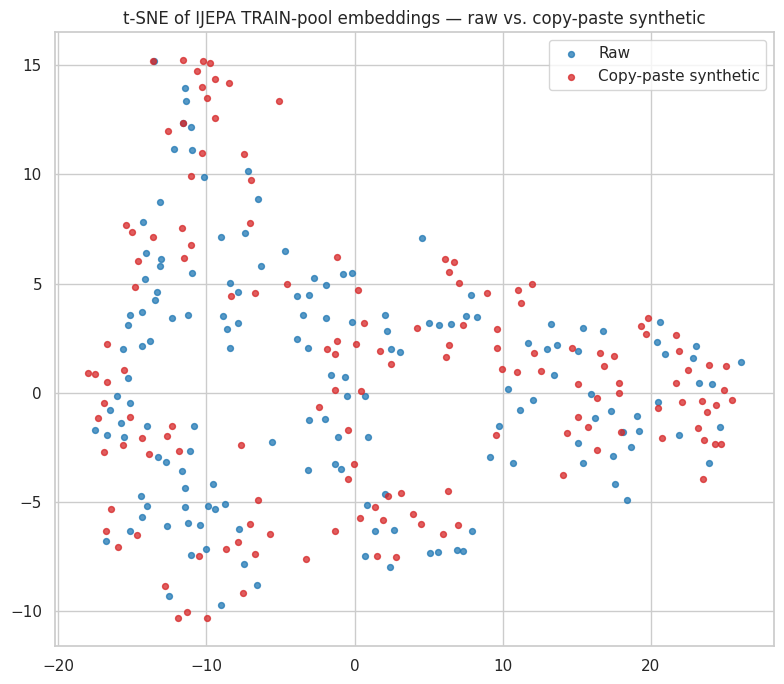

In [17]:
TRAIN_DIAGNOSTIC_LIMIT = 300
train_stem_set_raw = set(stems_train)
train_sample_paths = train_images if len(train_images) <= TRAIN_DIAGNOSTIC_LIMIT else random.Random(SEED).sample(train_images, TRAIN_DIAGNOSTIC_LIMIT)

train_feats, train_is_synthetic = [], []
with torch.inference_mode():
    for p in tqdm(train_sample_paths, desc="Embedding train-pool images"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(encoder(x).flatten(1), dim=1)
        train_feats.append(feat.squeeze(0).cpu().numpy())
        train_is_synthetic.append(p.stem not in train_stem_set_raw)

train_feature_matrix = np.stack(train_feats)
print("Raw:", train_is_synthetic.count(False), "| Copy-paste synthetic:", train_is_synthetic.count(True))

perplexity_train = min(30.0, max(2.0, (len(train_feature_matrix) - 1) / 3))
tsne_train_xy = TSNE(n_components=2, random_state=SEED, perplexity=perplexity_train).fit_transform(train_feature_matrix)

fig, ax = plt.subplots(figsize=(8, 7))
for flag, label, color in [(False, "Raw", "tab:blue"), (True, "Copy-paste synthetic", "tab:red")]:
    idx = [i for i, s in enumerate(train_is_synthetic) if s == flag]
    ax.scatter(tsne_train_xy[idx, 0], tsne_train_xy[idx, 1], label=label, s=18, alpha=0.75, c=color)
ax.legend(); ax.set_title(f"t-SNE of {METHOD.upper()} TRAIN-pool embeddings — raw vs. copy-paste synthetic")
plt.tight_layout(); plt.show()

## 14. Quantitative collapse diagnostics — beyond eyeballing one query

Same rigorous test used for BYOL and SimCLR — I-JEPA shares BYOL's EMA-target/no-negatives structure,
so this is the primary evidence for whether it collapsed, not the single-query nearest-neighbour panel.


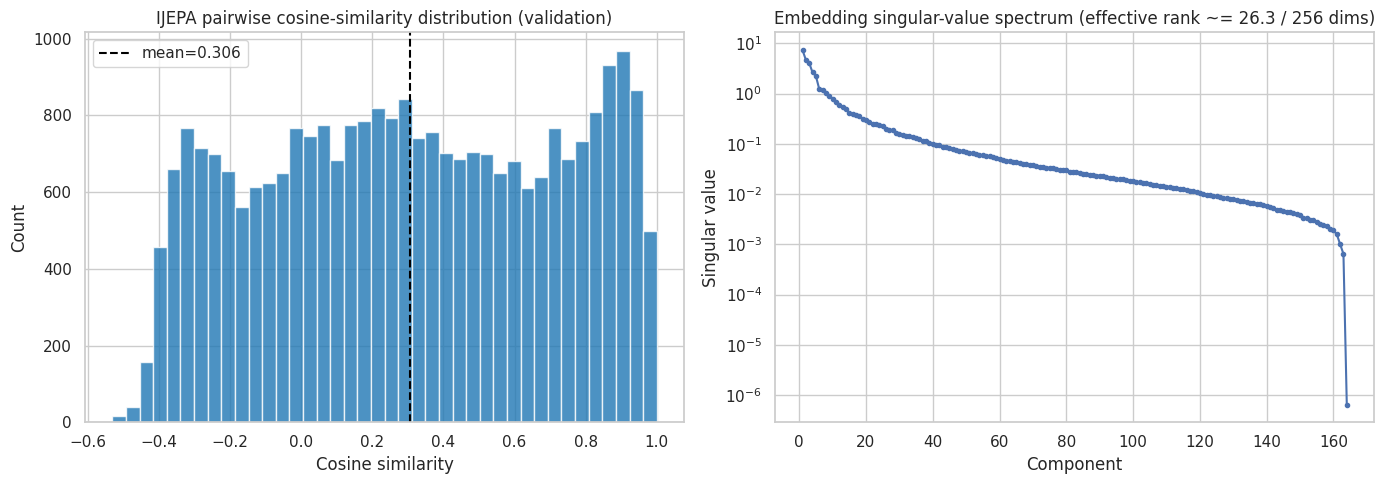

mean pairwise similarity                                       0.3058
std pairwise similarity                                        0.4079
effective rank                                                  26.33
embedding dimensionality                                          256
collapse read               no strong collapse signature by this test
dtype: object

In [18]:
pairwise_sims = cosine_similarity(feature_matrix)
off_diagonal = pairwise_sims[~np.eye(len(pairwise_sims), dtype=bool)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(off_diagonal, bins=40, color="tab:blue", alpha=0.8)
axes[0].axvline(off_diagonal.mean(), color="black", linestyle="--", label=f"mean={off_diagonal.mean():.3f}")
axes[0].set_title(f"{METHOD.upper()} pairwise cosine-similarity distribution (validation)")
axes[0].set_xlabel("Cosine similarity"); axes[0].set_ylabel("Count"); axes[0].legend()

singular_values = np.linalg.svd(feature_matrix - feature_matrix.mean(axis=0), compute_uv=False)
normalized_sv = singular_values / singular_values.sum()
effective_rank = float(np.exp(-(normalized_sv * np.log(normalized_sv + 1e-12)).sum()))
axes[1].plot(range(1, len(singular_values) + 1), singular_values, marker="o", markersize=3)
axes[1].set_title(f"Embedding singular-value spectrum (effective rank ~= {effective_rank:.1f} / {feature_matrix.shape[1]} dims)")
axes[1].set_xlabel("Component"); axes[1].set_ylabel("Singular value"); axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

pd.Series({
    "mean pairwise similarity": round(float(off_diagonal.mean()), 4),
    "std pairwise similarity": round(float(off_diagonal.std()), 4),
    "effective rank": round(effective_rank, 2),
    "embedding dimensionality": feature_matrix.shape[1],
    "collapse read": ("LIKELY COLLAPSED - similarities tightly clustered near 1.0 and/or effective rank very low"
                       if off_diagonal.mean() > 0.9 and off_diagonal.std() < 0.05
                       else "no strong collapse signature by this test"),
})

## 15. Exercise — target-block ablation (more, smaller target blocks)

The reference tutorial's own exercise: retrain with more numerous, smaller target blocks
(`num_target_blocks=8`, `target_scale=(0.05, 0.15)` instead of the main run's `4` blocks at
`(0.10, 0.25)`), keeping the same seed and validation images for a fair comparison.


In [19]:
from dataclasses import replace

exercise_config = replace(
    config,
    num_target_blocks=8,
    target_scale_min=0.05,
    target_scale_max=0.15,
    epochs=50,
    warmup_epochs=3,
    output_dir=f"/kaggle/working/{METHOD}_kiitmita_8blocks",
).validate()

pd.Series({
    "target blocks": exercise_config.num_target_blocks,
    "target scale": (exercise_config.target_scale_min, exercise_config.target_scale_max),
    "epochs": exercise_config.epochs,
    "output directory": exercise_config.output_dir,
})

target blocks                                            8
target scale                                  (0.05, 0.15)
epochs                                                  50
output directory    /kaggle/working/ijepa_kiitmita_8blocks
dtype: object

In [20]:
exercise_result = launch_distributed_pretrain(
    exercise_config, num_processes=GPU_COUNT,
    config_path=f"{exercise_config.output_dir}/ijepa_8blocks_config.yaml", check=True,
)

IJEPA 01/50: 100%|██████████| 37/37 [00:35<00:00,  1.05it/s, ema=0.99600, loss=0.3959, lr=1.03e-04]


Epoch 01 | loss=0.39605 | time=35.2s


IJEPA 02/50: 100%|██████████| 37/37 [00:12<00:00,  3.08it/s, ema=0.99602, loss=0.0219, lr=2.03e-04]


Epoch 02 | loss=0.02190 | time=12.0s


IJEPA 03/50: 100%|██████████| 37/37 [00:11<00:00,  3.13it/s, ema=0.99603, loss=0.0138, lr=3.00e-04]


...

Epoch 49 | loss=0.04559 | time=12.0s


IJEPA 50/50: 100%|██████████| 37/37 [00:12<00:00,  3.03it/s, ema=1.00000, loss=0.0443, lr=3.00e-06]


Epoch 50 | loss=0.04427 | time=12.2s


/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


{
  "output_dir": "/kaggle/working/ijepa_kiitmita_8blocks",
  "yolo_checkpoint": "/kaggle/working/ijepa_kiitmita_8blocks/ijepa_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_kiitmita_8blocks/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_kiitmita_8blocks/history.csv",
  "manifest_json": "/kaggle/working/ijepa_kiitmita_8blocks/run_manifest.json"
}
{
  "output_dir": "/kaggle/working/ijepa_kiitmita_8blocks",
  "yolo_checkpoint": "/kaggle/working/ijepa_kiitmita_8blocks/ijepa_pretrained_yolo26n.pt",
  "ssl_checkpoint": "/kaggle/working/ijepa_kiitmita_8blocks/last_ssl.pt",
  "history_csv": "/kaggle/working/ijepa_kiitmita_8blocks/history.csv",
  "manifest_json": "/kaggle/working/ijepa_kiitmita_8blocks/run_manifest.json"
}


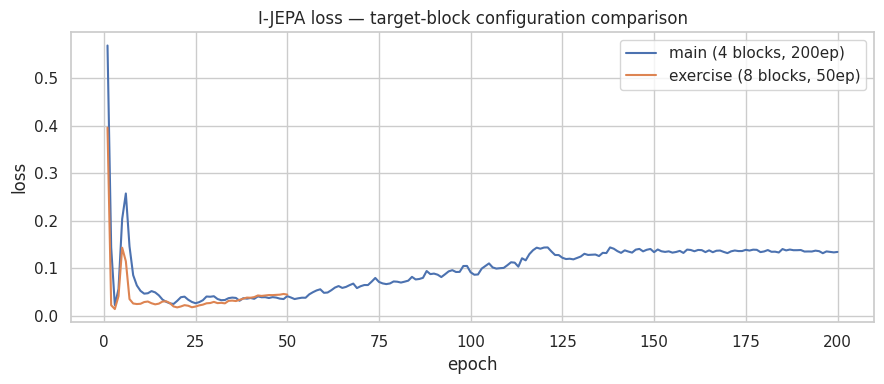

In [21]:
exercise_history = pd.read_csv(f"{exercise_config.output_dir}/history.csv")

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=history, x="epoch", y="loss", label="main (4 blocks, 200ep)", ax=ax)
sns.lineplot(data=exercise_history, x="epoch", y="loss", label="exercise (8 blocks, 50ep)", ax=ax)
ax.set_title("I-JEPA loss — target-block configuration comparison")
plt.tight_layout(); plt.show()

Feature extraction on the *same* validation images as the main run, for a fair comparison.

In [22]:
exercise_manifest = json.loads((Path(exercise_config.output_dir) / "run_manifest.json").read_text())
EXERCISE_YOLO_CHECKPOINT = Path(exercise_manifest["outputs"]["yolo_checkpoint"])

exercise_detector = YOLO(str(EXERCISE_YOLO_CHECKPOINT))
exercise_encoder = YOLOBackboneEncoder(exercise_detector.model).to(DEVICE).eval()

exercise_feats = []
with torch.inference_mode():
    for p in tqdm(selected_paths, desc="Embedding val images (8 blocks)"):
        x = infer_tf(Image.open(p).convert("RGB")).unsqueeze(0).to(DEVICE)
        feat = torch.nn.functional.normalize(exercise_encoder(x).flatten(1), dim=1)
        exercise_feats.append(feat.squeeze(0).cpu().numpy())
exercise_feature_matrix = np.stack(exercise_feats)

Embedding val images (8 blocks):   0%|          | 0/164 [00:00<?, ?it/s]

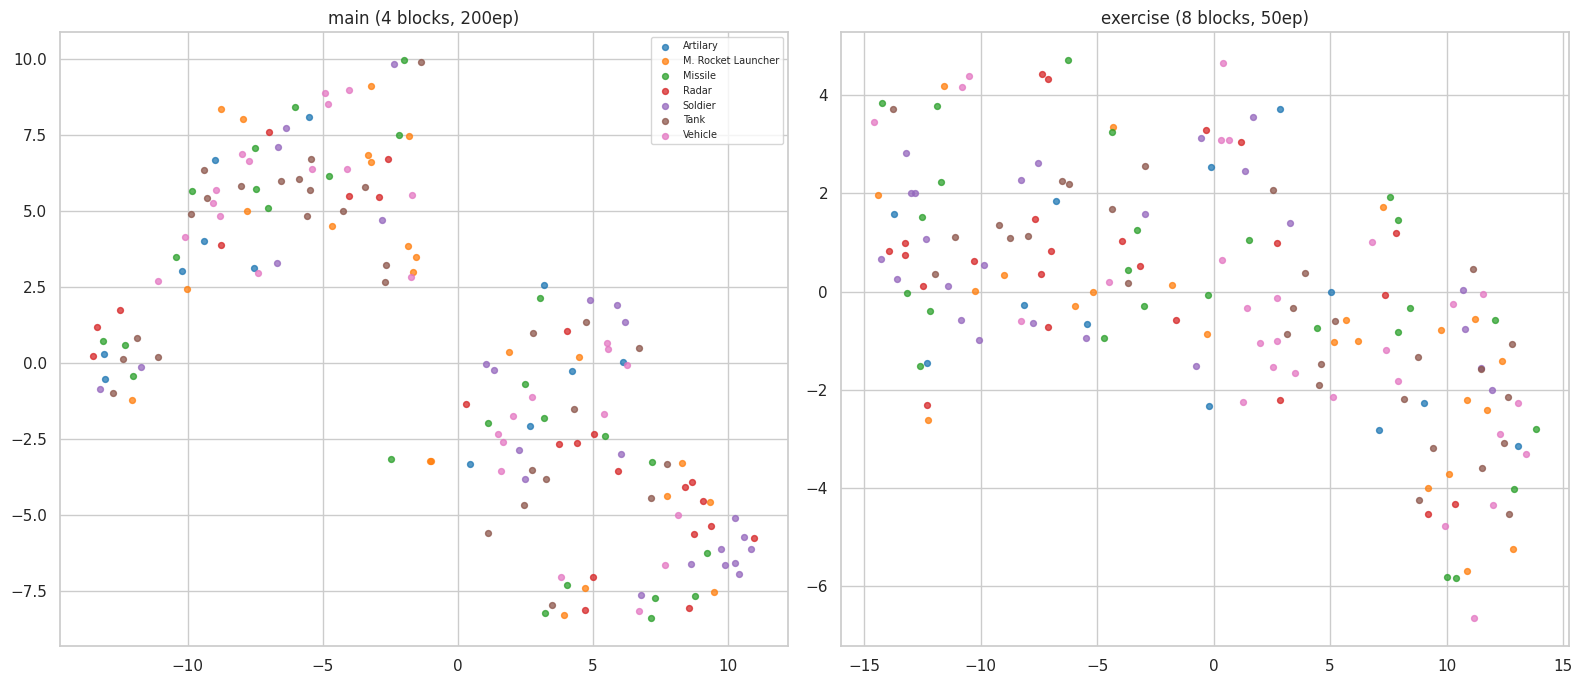

In [23]:
tsne_main = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(feature_matrix)
tsne_exercise = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(exercise_feature_matrix)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, xy, title in [(axes[0], tsne_main, "main (4 blocks, 200ep)"), (axes[1], tsne_exercise, "exercise (8 blocks, 50ep)")]:
    for color, cls in zip(palette, sorted(set(point_classes))):
        idx = [i for i, c in enumerate(point_classes) if c == cls]
        ax.scatter(xy[idx, 0], xy[idx, 1], label=cls, s=18, alpha=0.75, color=color)
    ax.set_title(title)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [24]:
def collapse_stats(fm):
    sims = cosine_similarity(fm)
    off = sims[~np.eye(len(sims), dtype=bool)]
    sv = np.linalg.svd(fm - fm.mean(axis=0), compute_uv=False)
    p = sv / sv.sum()
    eff_rank = float(np.exp(-(p * np.log(p + 1e-12)).sum()))
    return off.mean(), off.std(), eff_rank

mean_main, std_main, rank_main = collapse_stats(feature_matrix)
mean_ex, std_ex, rank_ex = collapse_stats(exercise_feature_matrix)

pd.DataFrame({
    "main (4 blocks, 200ep)": [mean_main, std_main, rank_main],
    "exercise (8 blocks, 50ep)": [mean_ex, std_ex, rank_ex],
}, index=["mean pairwise similarity", "std pairwise similarity", "effective rank"]).round(4)

,"main (4 blocks, 200ep)","exercise (8 blocks, 50ep)"
mean pairwise similarity,0.3058,0.4672
std pairwise similarity,0.4079,0.4163
effective rank,26.3278,20.8963


## 16. Publish the checkpoint for Notebook 3b

Run *Save & Run All (Commit)*, then attach this notebook's output as an input to `group02-partB-03b-ijepa-detect`.

In [25]:
print("Attach this notebook as a Kaggle input to Notebook 3b.")
print("SSL checkpoint:", SSL_CHECKPOINT)
print("YOLO checkpoint:", YOLO_CHECKPOINT)

Attach this notebook as a Kaggle input to Notebook 3b.
SSL checkpoint: /kaggle/working/ijepa_kiitmita/last_ssl.pt
YOLO checkpoint: /kaggle/working/ijepa_kiitmita/ijepa_pretrained_yolo26n.pt
